In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, MinMaxScaler
from sklearn.linear_model import LinearRegression, SGDRegressor, MultiTaskLasso, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

In [476]:
df = pd.read_csv('/Users/apple/Desktop/Projects/Review Data Science/messy_housing_data.csv')
df.head()

,area_sqft,bedrooms,bathrooms,year_built,price,location
0,2696,4.00,1,"1,962.00",2068779.98,austin
1,2017,6.00,4,"2,008.00",1539208.46,San Francisco
2,1592,3.00,3,"1,991.00",557909.7,San Francisco
3,3358,2.00,4,"1,914.00",NaN,chicago
4,1624,2.00,5,"1,935.00",716945.96,New York City


In [477]:
df.isnull().sum()

area_sqft      0
bedrooms      21
bathrooms      0
year_built    36
price         50
location       0
dtype: int64

In [478]:
df.value_counts()

area_sqft  bedrooms  bathrooms  year_built  price       location     
2874       1.00      1          1,994.00    2023776.94  Boston           2
3857       1.00      4          1,970.00    1121087.17  los angeles      2
4281       4.00      4          1,976.00    1871382.95  Bostan           2
1139       2.00      3          1,915.00    496344.73   nyc              2
2129       5.00      1          2,022.00    1108994.39  san francisco    2
                                                                        ..
1878       1.00      3          2,001.00    1030980.32  miami            1
1877       2.00      5          2,008.00    18770       New York City    1
1870       5.00      4          1,933.00    1463021.77  l.a.             1
1864       5.00      5          1,963.00    515892.38   Los Angeles      1
4999       6.00      4          1,982.00    2615033.93  san francisco    1
Name: count, Length: 310, dtype: int64

Let's drop the location line firstly, coz there are too many types of location or cities, that's why no need to use them to predict the price!


Let's drop NaN values in prices, coz it gets too messy in prediction, or decreases the accuracy rate  in the end.


In [479]:
df3 = pd.read_csv('messy_housing_data.csv')
df3.head()
df3.columns

Index(['area_sqft', 'bedrooms', 'bathrooms', 'year_built', 'price',
       'location'],
      dtype='object')

In [480]:
df3.dropna(inplace=True)
df3.head()

,area_sqft,bedrooms,bathrooms,year_built,price,location
0,2696,4.00,1,"1,962.00",2068779.98,austin
1,2017,6.00,4,"2,008.00",1539208.46,San Francisco
2,1592,3.00,3,"1,991.00",557909.7,San Francisco
4,1624,2.00,5,"1,935.00",716945.96,New York City
5,924,2.00,4,"1,972.00",574438.17,Chicago


In [481]:
df3.drop(columns = 'location', inplace = True)
df3.head()

,area_sqft,bedrooms,bathrooms,year_built,price
0,2696,4.00,1,"1,962.00",2068779.98
1,2017,6.00,4,"2,008.00",1539208.46
2,1592,3.00,3,"1,991.00",557909.7
4,1624,2.00,5,"1,935.00",716945.96
5,924,2.00,4,"1,972.00",574438.17


In [482]:
print(f'''{df3.info()}
      {df.info()}
      ''')

<class 'pandas.core.frame.DataFrame'>
Index: 324 entries, 0 to 419
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   area_sqft   324 non-null    int64  
 1   bedrooms    324 non-null    float64
 2   bathrooms   324 non-null    int64  
 3   year_built  324 non-null    float64
 4   price       324 non-null    object 
dtypes: float64(2), int64(2), object(1)
memory usage: 15.2+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   area_sqft   420 non-null    int64  
 1   bedrooms    399 non-null    float64
 2   bathrooms   420 non-null    int64  
 3   year_built  384 non-null    float64
 4   price       370 non-null    object 
 5   location    420 non-null    object 
dtypes: float64(2), int64(2), object(2)
memory usage: 19.8+ KB
None
      None
      


In [483]:
df3.price.value_counts()

df3 = df3[df3.price != 'unavailable']
df3[df3['price'].duplicated()]
df3.corrwith(df3.price)

area_sqft     0.71
bedrooms      0.07
bathrooms    -0.06
year_built    0.07
price         1.00
dtype: float64

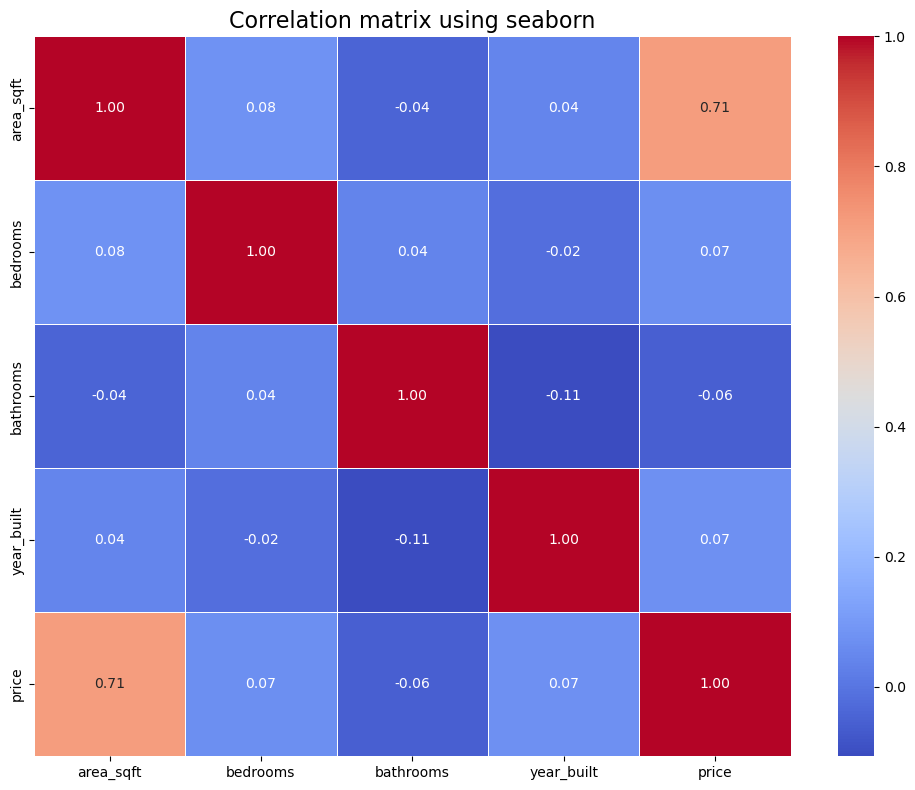

In [484]:
corr_matrix = df3.corr()
plt.figure(figsize = (10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.4)

plt.title('Correlation matrix using seaborn', fontsize = 16)
plt.tight_layout() # Ensures nothing gets cut off
plt.show()


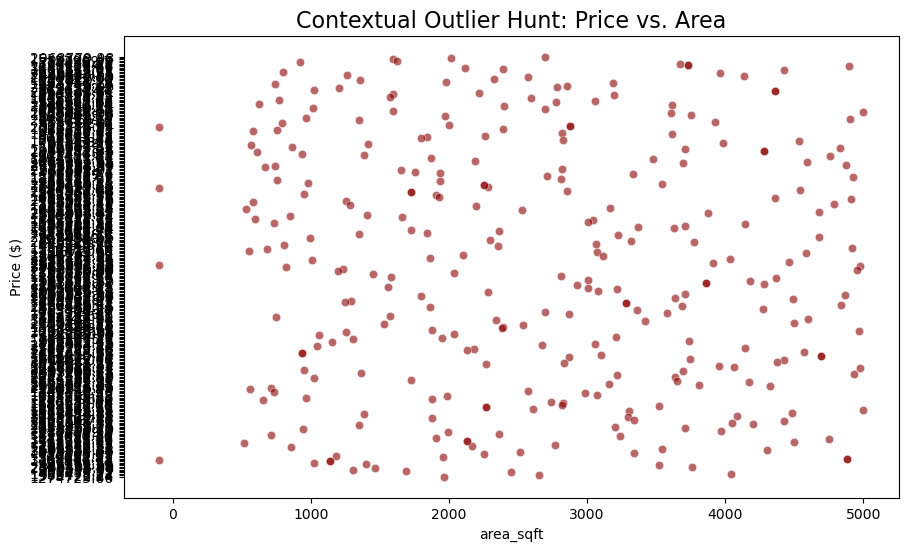

In [485]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df3, x='area_sqft', y='price', alpha=0.6, color='darkred')

plt.title('Contextual Outlier Hunt: Price vs. Area', fontsize=16)
plt.ylabel('Price ($)')
plt.show()

As we can see through this correlation matrix, there is almost no correlation between other columns except areas and price, so we can just use linear regression to predict the prices!


### MinMaxScaler


In [486]:
scaler = MinMaxScaler()

In [ ]:
df3_array = scaler.fit_transform(df3)
df3_scalled = pd.DataFrame(df3_array, columns=df3.columns)
df3_scalled.head()

,area_sqft,bedrooms,bathrooms,year_built,price
0,0.55,0.16,0.00,0.49,0.28
1,0.42,0.26,0.75,0.86,0.20
2,0.33,0.11,0.50,0.72,0.07
3,0.34,0.05,1.00,0.28,0.09
4,0.20,0.05,0.75,0.57,0.08


### Model splitting

In [488]:
lr = LinearRegression()
logr = LogisticRegression()
X = df3.drop('price', axis = 1)
y = df3.price

In [489]:
X_train, X_test, y_train,  y_test = train_test_split(X, y,test_size=0.2, random_state=42, shuffle=True)

In [490]:
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)

Training Features Shape: (254, 4)
Testing Features Shape: (64, 4)


### Model training

In [491]:
linear_model = lr.fit(X_train, y_train)
y_pred = linear_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

# 3. Calculate R-squared
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2) Score: {r2:.4f}")

Mean Squared Error (MSE): 273018101754.24
Root Mean Squared Error (RMSE): 522511.34
R-squared (R2) Score: 0.5679


In [492]:
# Find the difference between test sample and prediction sample

differences = pd.DataFrame({'Actual': y_test,
                            'Prediction':y_pred})


pd.options.display.float_format = '{:,.2f}'.format

differences.head(15)

,Actual,Prediction
99,1463021.77,"935,832.60"
361,1108994.39,"1,196,405.83"
33,2551135.51,"2,192,376.09"
333,1864854.82,"1,644,512.78"
15,1637513.07,"1,253,079.56"
135,654445.57,"1,049,099.62"
226,745706.57,"706,633.54"
242,28660,"1,547,204.52"
87,658374.8,"825,757.27"
151,1187477.73,"861,549.67"


In [493]:
df.location.unique()

array(['austin', 'San Francisco', 'chicago', 'New York City', 'Chicago',
       'miami', 'san francisco', 'LA', 'l.a.', 'AUSTIN ', 'Austin',
       'Los Angeles ', 'La ', 'Chicago ', 'SF', 'boston', 'Chicgo', 'nyc',
       'Boston', 'Los Angeles', 'los angeles', 'NYC', 'New York city',
       'NEW YORK CITY', 'LOS ANGELES ', 'Austin ', 'sf', 'San Francisco ',
       'L.A.', 'Miami', 'Bostan', 'Boston ', 'Miami ', 'SAN FRANCISCO',
       'L.A. ', 'Sf ', 'New York City ', 'BOSTON', 'CHICAGO ', 'Nyc ',
       'CHICAGO', 'AUSTIN', 'MIAMI'], dtype=object)

In [494]:
df.location.value_counts().size

43

In [495]:
df['location'] = df['location'].replace(['austin','AUSTIN ', 'Austin','Austin ','AUSTIN'], 'Austin')
df['location'] = df['location'].replace(['San Francisco','san francisco', 'SF','sf','San Francisco ','SAN FRANCISCO','Sf '], 'San Francisco')
df['location'] = df['location'].replace(['chicago','Chicago', 'Chicago ','Chicgo','CHICAGO','CHICAGO '], 'Chicago')
df['location'] = df['location'].replace(['New York City','nyc', 'NYC','New York city','NEW YORK CITY','New York City ','Nyc '], 'New York')
df['location'] = df['location'].replace(['miami','Miami ', 'Miami ','MIAMI ','Miami', 'MIAMI'], 'Miami')
df['location'] = df['location'].replace(['LA','l.a.', 'Los Angeles ','La ','Los Angeles','los angeles','LOS ANGELES ','L.A.','L.A. '], 'Los Angeles')
df['location'] = df['location'].replace(['boston','Boston ', 'Bostan','Boston ','BOSTON'], 'Boston')

In [496]:
df.location.value_counts().is_unique

True

In [497]:
df.location.value_counts()

location
San Francisco    85
Los Angeles      77
New York         75
Austin           53
Chicago          50
Boston           46
Miami            34
Name: count, dtype: int64

In [498]:
ohe = OneHotEncoder(drop='first',sparse_output=False)
column = ['location']
encoded_array = ohe.fit_transform(df[column])
new_column_names = ohe.get_feature_names_out(column)
encoded_df = pd.DataFrame(encoded_array, columns=new_column_names, index=df.index)
df_ready = pd.concat([df, encoded_df], axis=1)
df_ready.drop(columns='location', inplace = True)
df_ready.head(10)

,area_sqft,bedrooms,bathrooms,year_built,price,location_Boston,location_Chicago,location_Los Angeles,location_Miami,location_New York,location_San Francisco
0,2696,4.00,1,"1,962.00",2068779.98,0.00,0.00,0.00,0.00,0.00,0.00
1,2017,6.00,4,"2,008.00",1539208.46,0.00,0.00,0.00,0.00,0.00,1.00
2,1592,3.00,3,"1,991.00",557909.7,0.00,0.00,0.00,0.00,0.00,1.00
3,3358,2.00,4,"1,914.00",NaN,0.00,1.00,0.00,0.00,0.00,0.00
4,1624,2.00,5,"1,935.00",716945.96,0.00,0.00,0.00,0.00,1.00,0.00
5,924,2.00,4,"1,972.00",574438.17,0.00,1.00,0.00,0.00,0.00,0.00
6,1922,3.00,1,"1,927.00",NaN,0.00,0.00,0.00,1.00,0.00,0.00
7,4463,2.00,3,NaN,NaN,0.00,0.00,0.00,0.00,0.00,1.00
8,3674,1.00,1,"1,900.00",1974364.8,0.00,0.00,1.00,0.00,0.00,0.00
9,3729,1.00,2,"1,913.00",1489205.48,0.00,0.00,1.00,0.00,0.00,0.00


In [499]:
missing_rows = df_ready.isna().any(axis=1)
df_ready[missing_rows].head(20)

,area_sqft,bedrooms,bathrooms,year_built,price,location_Boston,location_Chicago,location_Los Angeles,location_Miami,location_New York,location_San Francisco
3,3358,2.00,4,"1,914.00",NaN,0.00,1.00,0.00,0.00,0.00,0.00
6,1922,3.00,1,"1,927.00",NaN,0.00,0.00,0.00,1.00,0.00,0.00
7,4463,2.00,3,NaN,NaN,0.00,0.00,0.00,0.00,0.00,1.00
11,808,NaN,1,NaN,542187.73,0.00,0.00,0.00,0.00,0.00,0.00
13,1593,1.00,4,"1,967.00",NaN,0.00,0.00,0.00,0.00,0.00,0.00
14,1778,2.00,1,NaN,1165755.41,0.00,0.00,1.00,0.00,0.00,0.00
23,1432,3.00,5,"2,022.00",NaN,0.00,0.00,1.00,0.00,0.00,0.00
26,4240,5.00,5,NaN,NaN,1.00,0.00,0.00,0.00,0.00,0.00
34,802,3.00,1,"2,003.00",NaN,0.00,0.00,0.00,0.00,0.00,0.00
35,826,5.00,5,"1,956.00",NaN,0.00,0.00,0.00,0.00,1.00,0.00


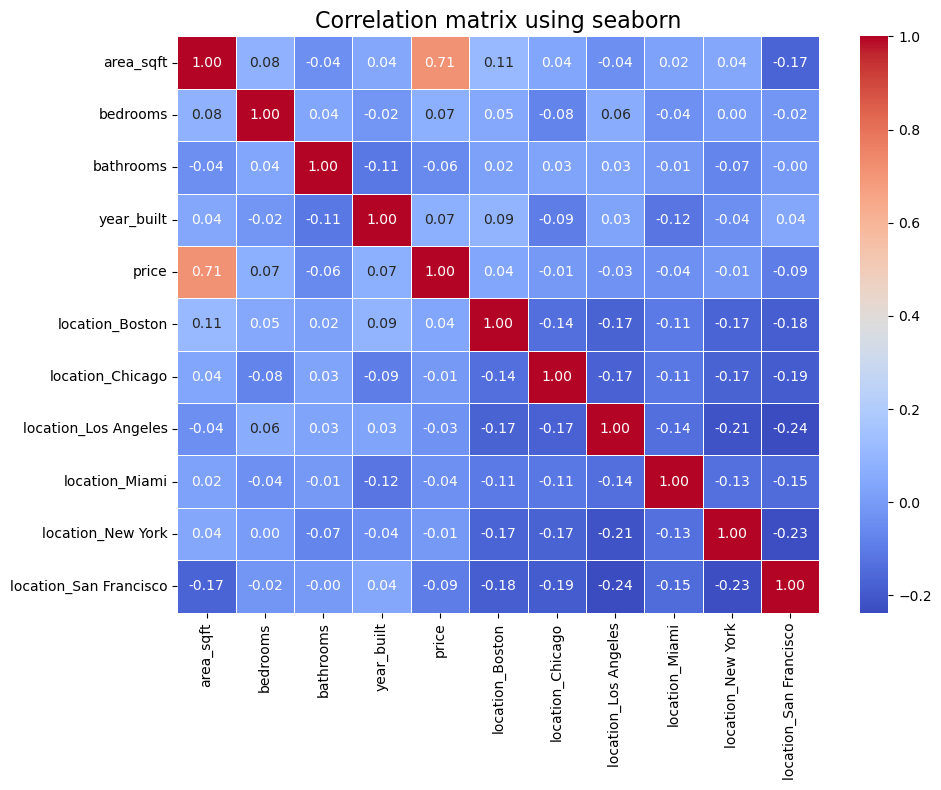

In [500]:
df_ready.dropna(inplace=True)
df_ready.isnull().sum()
df_ready = df_ready[df_ready.price != 'unavailable']
df_ready.price.drop_duplicates(inplace=True)
df_ready['price'] = pd.to_numeric(df_ready['price'], errors='coerce')
corr_matrix = df_ready.corr(numeric_only=True)
plt.figure(figsize = (10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.4)

plt.title('Correlation matrix using seaborn', fontsize = 16)
plt.tight_layout() # Ensures nothing gets cut off
plt.show()

In [502]:
df_ready.shape

(318, 11)

In [503]:
df_ready.columns

Index(['area_sqft', 'bedrooms', 'bathrooms', 'year_built', 'price',
       'location_Boston', 'location_Chicago', 'location_Los Angeles',
       'location_Miami', 'location_New York', 'location_San Francisco'],
      dtype='object')

In [505]:
columns = ['area_sqft', 'bedrooms', 'bathrooms', 'year_built',
       'location_Boston', 'location_Chicago', 'location_Los Angeles',
       'location_Miami', 'location_New York', 'location_San Francisco']


In [507]:
df_ready_array = scaler.fit_transform(df_ready)
df_ready_scalled = pd.DataFrame(df_ready_array, columns=df_ready.columns)
df_ready_scalled.head()

,area_sqft,bedrooms,bathrooms,year_built,price,location_Boston,location_Chicago,location_Los Angeles,location_Miami,location_New York,location_San Francisco
0,0.55,0.16,0.00,0.49,0.28,0.00,0.00,0.00,0.00,0.00,0.00
1,0.42,0.26,0.75,0.86,0.20,0.00,0.00,0.00,0.00,0.00,1.00
2,0.33,0.11,0.50,0.72,0.07,0.00,0.00,0.00,0.00,0.00,1.00
3,0.34,0.05,1.00,0.28,0.09,0.00,0.00,0.00,0.00,1.00,0.00
4,0.20,0.05,0.75,0.57,0.08,0.00,1.00,0.00,0.00,0.00,0.00


In [ ]:
X = df_ready[columns ]
y= df_ready['price']
X_train, X_test, y_train,  y_test = train_test_split(X, y,test_size=0.2, random_state=42, shuffle=True)
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)

In [ ]:
linear_model = lr.fit(X_train, y_train)
y_pred = linear_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

# 3. Calculate R-squared
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2) Score: {r2:.4f}")